# BERTopic Analysis: Unsupervised Topic Discovery in UNSC Speeches on Tigray

## Overview

This notebook applies BERTopic (Grootendorst, 2022) to discover latent topics in UN Security Council speeches on the Tigray conflict. BERTopic is the current standard for topic modeling in computational social science, replacing LDA.

**Research Question:** How do UN Security Council member states frame the Tigray conflict, and how does framing vary across geopolitical blocs and over time?

**Corpus:** 88 text units extracted from 4 open UNSC meetings (July–November 2021), Secretary-General press releases (2021–2022), Eritrea letters, and a Council press statement.

## Method

BERTopic works in four stages:
1. **Embedding:** Each text is converted into a dense numerical vector using a pretrained sentence transformer (all-MiniLM-L6-v2). These vectors capture semantic meaning.
2. **Dimensionality reduction:** UMAP projects the high-dimensional embeddings into a lower-dimensional space suitable for clustering.
3. **Clustering:** HDBSCAN groups semantically similar texts into clusters without requiring a pre-specified number of topics.
4. **Topic representation:** c-TF-IDF extracts the most distinctive words per cluster to produce interpretable topic labels.

In [1]:
import os
import pandas as pd
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

# Set working directory
os.chdir("/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-text-analysis")

# Load the corpus
df = pd.read_csv("data/processed/corpus.csv", parse_dates=["date"])

print(f"Corpus loaded: {len(df)} text units")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nRole distribution:")
print(df["role"].value_counts())

/opt/anaconda3/envs/conflict-text/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Corpus loaded: 88 text units
Date range: 2021-02-02 to 2022-11-02

Role distribution:
role
council_member       48
president            18
secretary_general    10
invited_state         5
briefer               4
letter                2
council_statement     1
Name: count, dtype: int64


## Setup and Data Loading

import os
import pandas as pd
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

# Set working directory
os.chdir("/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-text-analysis")

# Load the corpus
df = pd.read_csv("data/processed/corpus.csv", parse_dates=["date"])

print(f"Corpus loaded: {len(df)} text units")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nRole distribution:")
print(df["role"].value_counts())
```

Also go back to Notebook 01 and add a Markdown cell at the very top (before your first code cell). Click on Cell 1, then press Escape and then A to insert a cell above. Change it to Markdown and paste:
```
# Data Collection and Corpus Construction

## Overview

This notebook extracts and structures a text corpus from UN Security Council records on the Tigray conflict (November 2020–November 2022). The corpus serves as the foundation for BERTopic topic modeling (Notebook 02) and LLM-based annotation (Notebook 03).

## Data Sources

- **4 UNSC verbatim records** (S/PV.8812, S/PV.8843, S/PV.8875, S/PV.8899): Open meeting transcripts containing individual speeches by Council members, briefers, and invited states.
- **10 Secretary-General press releases**: Short statements on key conflict developments.
- **1 Security Council press statement** (SC/14501): Collective Council position on Ethiopia.
- **2 letters from Eritrea** (S/2021/378, S/2021/510): Responses to Council discussions.

## Output

A structured corpus of 88 text units saved to `data/processed/corpus.csv`, with metadata including speaker name, country, role, date, and word count.

## Step 1: Generate Document Embeddings

We use the `all-MiniLM-L6-v2` sentence transformer to convert each text into a 384-dimensional vector. This model is lightweight and performs well on English text. The embeddings capture semantic similarity: texts about humanitarian access will cluster near each other even if they use different vocabulary.

In [2]:
# Generate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

docs = df["text"].tolist()
embeddings = embedding_model.encode(docs, show_progress_bar=True)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Each document is represented as a {embeddings.shape[1]}-dimensional vector")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18209.97it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 3/3 [00:02<00:00,  1.41it/s]

Embeddings shape: (88, 384)
Each document is represented as a 384-dimensional vector


## Step 2: Fit BERTopic Model

With 88 documents, we need to adjust the default UMAP and HDBSCAN parameters. The defaults assume larger corpora (thousands of documents). For a small corpus:
- **UMAP:** `n_neighbors=10` (default 15 is too high for 88 docs), `n_components=5`, `min_dist=0.0`
- **HDBSCAN:** `min_cluster_size=3` (default 10 would force most documents into the outlier category), `min_samples=2`

These settings allow the algorithm to find smaller, more specific clusters appropriate for our corpus size.

In [3]:
# Configure sub-models for small corpus
umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=3,
    min_samples=2,
    metric="euclidean",
    prediction_data=True
)

# Fit BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

# Summary
topic_info = topic_model.get_topic_info()
print(f"\nTopics found: {len(topic_info) - 1}")  # subtract 1 for outlier topic -1
print(f"Outlier documents (topic -1): {sum(t == -1 for t in topics)}")
print(f"Assigned documents: {sum(t != -1 for t in topics)}")
print(f"\nTopic overview:")
print(topic_info[["Topic", "Count", "Name"]].to_string())

2026-03-17 12:58:26,729 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-17 12:58:29,777 - BERTopic - Dimensionality - Completed ✓
2026-03-17 12:58:29,777 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-17 12:58:29,780 - BERTopic - Cluster - Completed ✓
2026-03-17 12:58:29,781 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-17 12:58:29,944 - BERTopic - Representation - Completed ✓



Topics found: 12
Outlier documents (topic -1): 12
Assigned documents: 76

Topic overview:
    Topic  Count                        Name
0      -1     12            -1_the_and_of_to
1       0     18             0_the_and_to_of
2       1      7  1_secretary_general_the_to
3       2      7              2_the_of_in_to
4       3      7   3_floor_give_briefing_now
5       4      7     4_the_nations_of_united
6       5      6             5_the_of_and_to
7       6      6             6_and_the_of_to
8       7      5             7_the_and_to_in
9       8      4              8_mr_ms_of_the
10      9      3             9_the_of_in_and
11     10      3            10_the_of_to_and
12     11      3             11_the_to_of_in


## Step 3: Improve Topic Representations

The initial c-TF-IDF labels are dominated by English stopwords ("the", "of", "and"). We re-fit the model with a custom CountVectorizer that removes stopwords, producing meaningful topic labels.

In [4]:
# Re-fit with stopword removal
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=2,           # word must appear in at least 2 documents
    ngram_range=(1, 2)  # include bigrams for richer labels
)

# Update the model's vectorizer and re-calculate topic representations
topic_model.update_topics(docs, vectorizer_model=vectorizer_model)

# Check new topic labels
topic_info = topic_model.get_topic_info()
print("=== IMPROVED TOPIC LABELS ===\n")
print(topic_info[["Topic", "Count", "Name"]].to_string())

# Show top words for each topic
print("\n=== TOP WORDS PER TOPIC ===\n")
for topic_id in range(len(topic_info) - 1):  # skip -1
    words = topic_model.get_topic(topic_id)
    if words:
        word_list = ", ".join([w[0] for w in words[:8]])
        print(f"Topic {topic_id} (n={topic_info[topic_info['Topic']==topic_id]['Count'].values[0]}): {word_list}")

=== IMPROVED TOPIC LABELS ===

    Topic  Count                                              Name
0      -1     12         -1_ethiopia_humanitarian_people_ethiopian
1       0     18             0_humanitarian_tigray_ethiopia_people
2       1      7  1_secretary general_secretary_general_reiterates
3       2      7            2_tigray_humanitarian_council_ethiopia
4       3      7                 3_floor_briefing_thank_statements
5       4      7             4_nations_united nations_united_staff
6       5      6                  5_ethiopia_africa_security_peace
7       6      6                  6_mexico_ethiopia_group_conflict
8       7      5          7_humanitarian_people_ethiopia_ethiopian
9       8      4                           8_mr_ms_speeches_record
10      9      3             9_eritrea_states_united states_united
11     10      3               10_process_ethiopia_conflict_tigray
12     11      3         11_humanitarian_conflict_ethiopia_general

=== TOP WORDS PER TOPIC ===

T

## Step 4: Add Topic Assignments to Corpus

We assign each document its topic label and merge back into the corpus dataframe. Topics 3 and 8 contain procedural content (presidential transitions, agenda adoption) rather than substantive framing. We flag these for potential exclusion in downstream analysis.

In [6]:
# Add topic assignments to the corpus
df["topic"] = topics
df["topic_prob"] = probs if isinstance(probs[0], (float, np.floating)) else [max(p) for p in probs]

# Create readable topic labels
topic_labels = {
    -1: "Outlier/Unassigned",
    0: "Humanitarian crisis & access",
    1: "SG press releases",
    2: "Council situation briefing",
    3: "Procedural (floor/briefing)",
    4: "UN operations & staff safety",
    5: "Peace, security & AU mediation",
    6: "Conflict dynamics & groups",
    7: "Humanitarian impact on civilians",
    8: "Procedural (agenda/record)",
    9: "Eritrea, US & accountability",
    10: "Political process & negotiations",
    11: "Conflict & humanitarian general",
}

df["topic_label"] = df["topic"].map(topic_labels)

# Show distribution
print("=== TOPIC DISTRIBUTION ===\n")
topic_dist = df.groupby(["topic", "topic_label"]).agg(
    count=("text_id", "count"),
    avg_words=("word_count", "mean")
).round(0)
print(topic_dist.to_string())

# Flag procedural topics
procedural_topics = [3, 8]
substantive = df[~df["topic"].isin(procedural_topics + [-1])]
print(f"\nSubstantive documents (excluding procedural and outliers): {len(substantive)} of {len(df)}")

=== TOPIC DISTRIBUTION ===

                                        count  avg_words
topic topic_label                                       
-1    Outlier/Unassigned                   12      865.0
 0    Humanitarian crisis & access         18      708.0
 1    SG press releases                     7      159.0
 2    Council situation briefing            7      303.0
 3    Procedural (floor/briefing)           7       51.0
 4    UN operations & staff safety          7      689.0
 5    Peace, security & AU mediation        6      743.0
 6    Conflict dynamics & groups            6      594.0
 7    Humanitarian impact on civilians      5      842.0
 8    Procedural (agenda/record)            4      283.0
 9    Eritrea, US & accountability          3      830.0
 10   Political process & negotiations      3      538.0
 11   Conflict & humanitarian general       3      791.0

Substantive documents (excluding procedural and outliers): 65 of 88


## Step 5: Visualize Topics

### 5a. Topic Distribution

Which frames dominate the UNSC discourse on Tigray? The bar chart below shows document counts per topic, excluding procedural content.

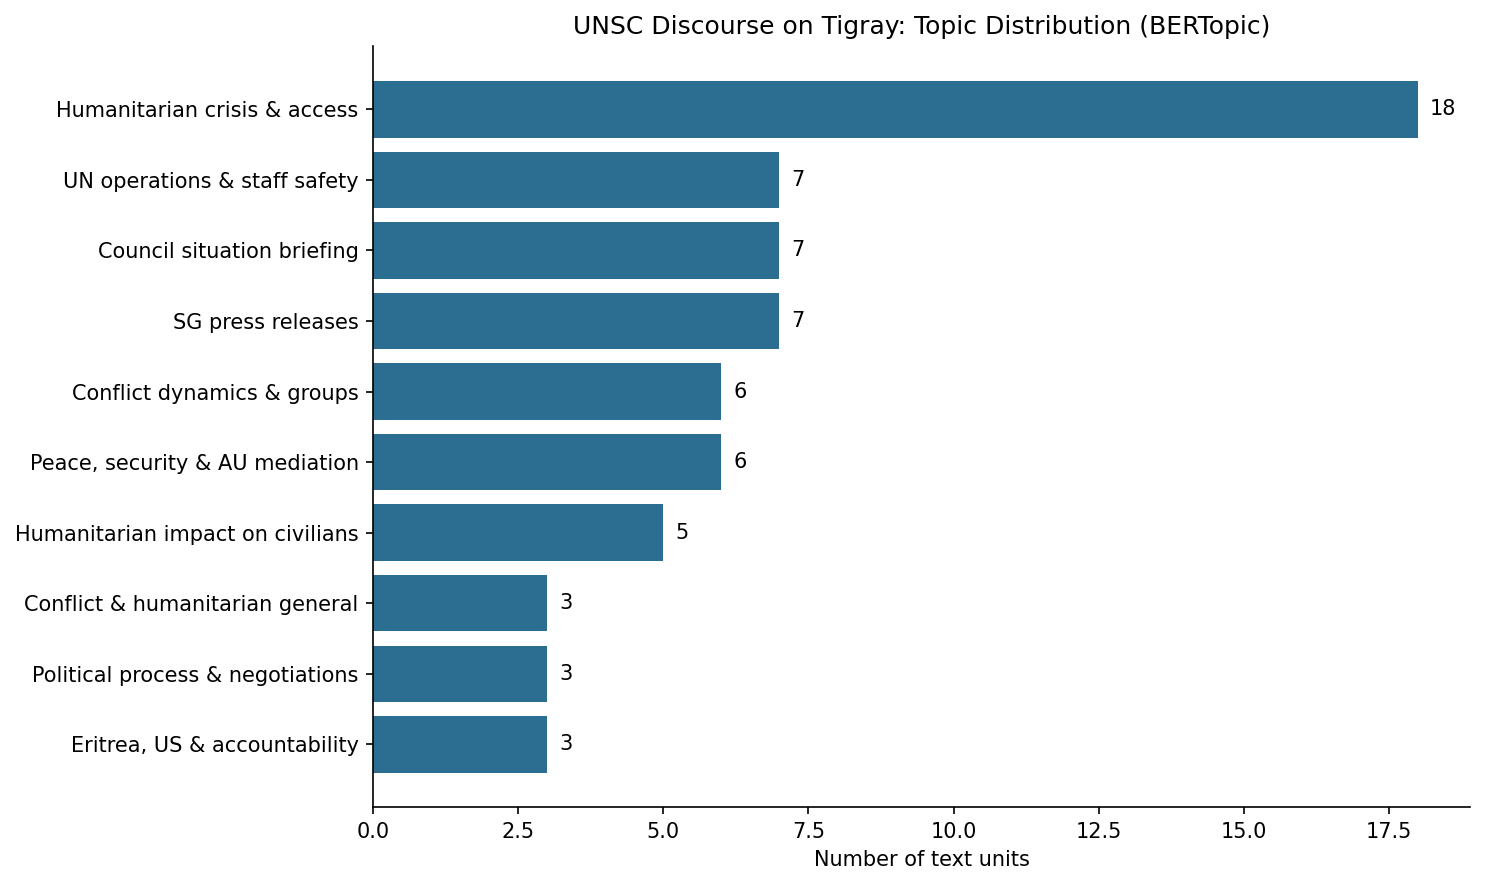

Saved to outputs/figures/topic_distribution.png


In [7]:
# Topic distribution bar chart (substantive topics only)
plot_data = df[~df["topic"].isin([-1, 3, 8])].groupby(
    ["topic", "topic_label"]
).size().reset_index(name="count").sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data["topic_label"], plot_data["count"], color="#2C6E91")
ax.set_xlabel("Number of text units")
ax.set_title("UNSC Discourse on Tigray: Topic Distribution (BERTopic)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, (count, label) in enumerate(zip(plot_data["count"], plot_data["topic_label"])):
    ax.text(count + 0.2, i, str(count), va="center", fontsize=10)

plt.tight_layout()
plt.savefig("outputs/figures/topic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/topic_distribution.png")

### 5b. Topics by Country

Which countries emphasize which frames? This cross-tabulation reveals whether geopolitical blocs differ in how they discuss the Tigray conflict. Western states (US, UK, Ireland, Norway, Estonia, France) are expected to emphasize humanitarian access and accountability. China and Russia are expected to emphasize sovereignty and non-interference.

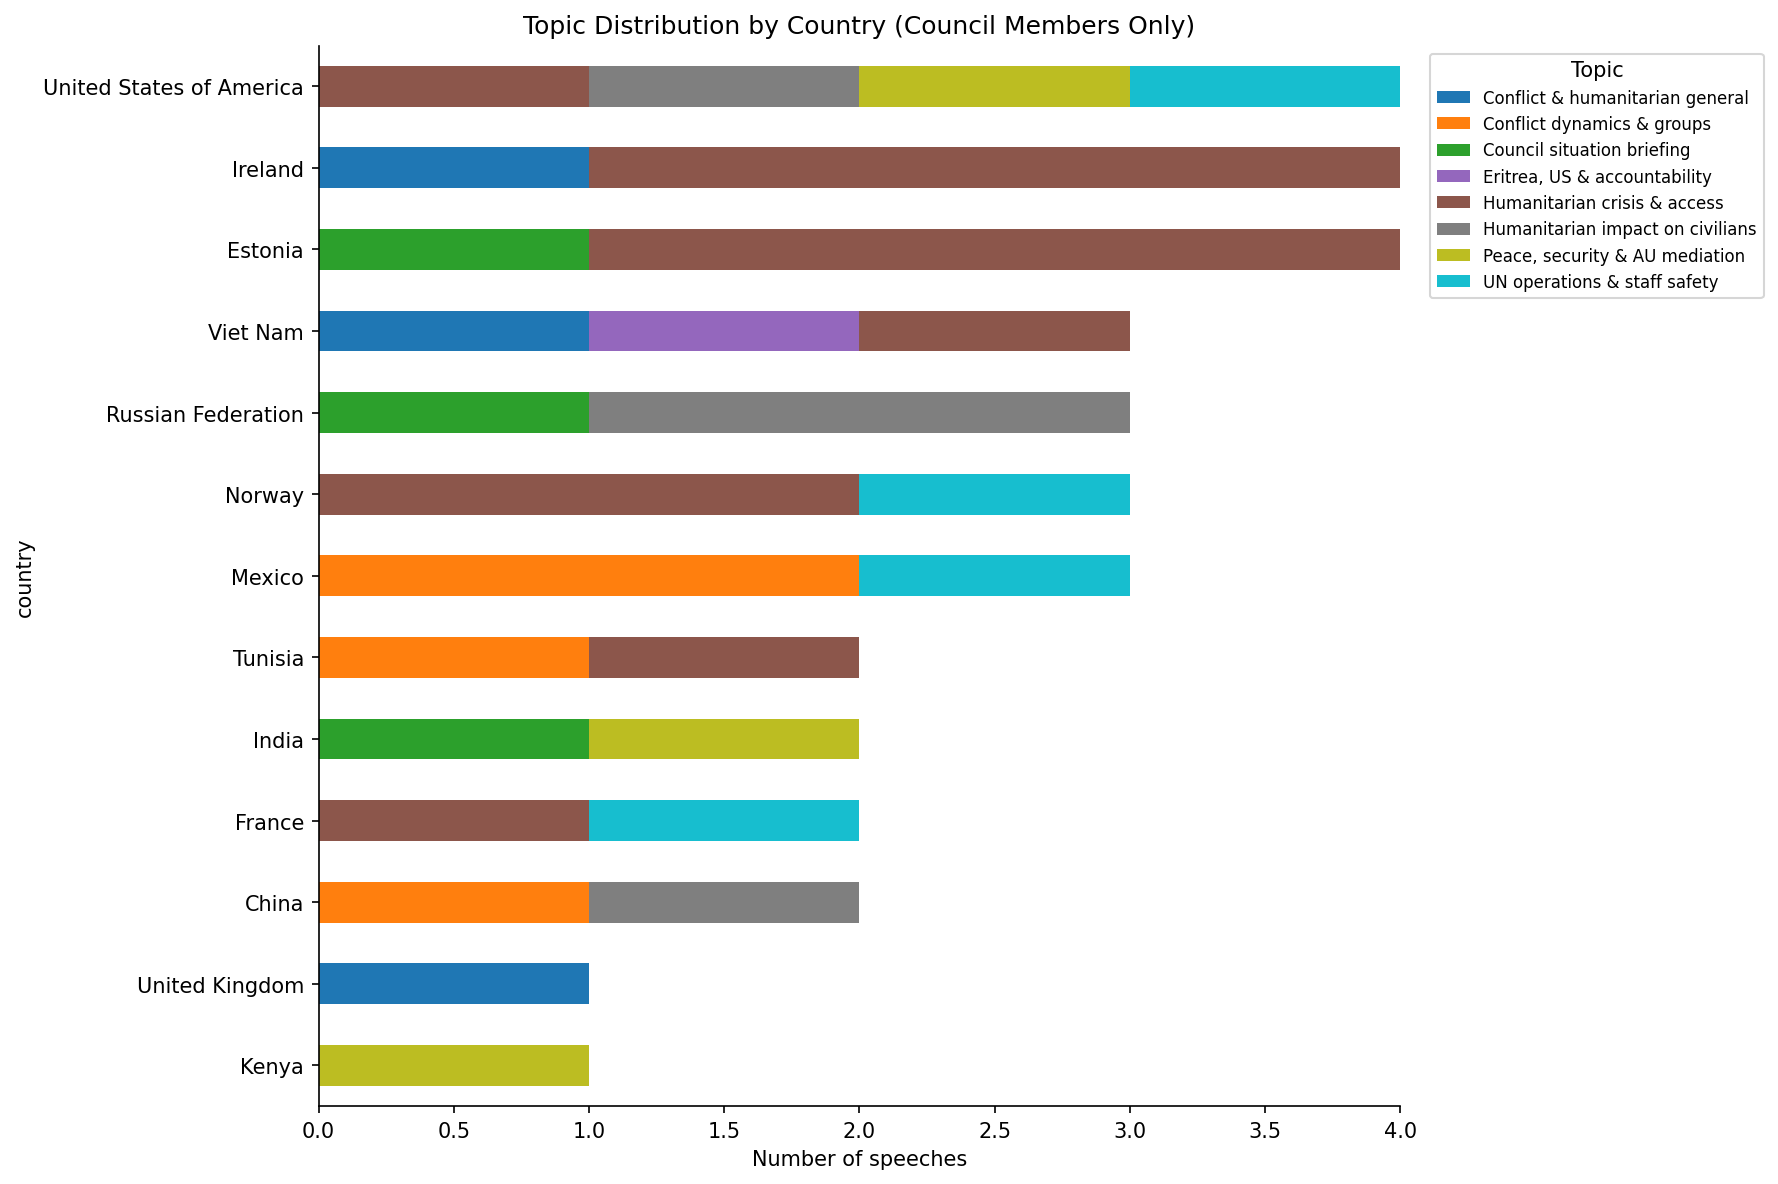

Saved to outputs/figures/topics_by_country.png


In [8]:
# Topics by country (council members only, substantive topics only)
members = df[(df["role"] == "council_member") & (~df["topic"].isin([-1, 3, 8]))]

# Cross-tabulation
ct = pd.crosstab(members["country"], members["topic_label"])

# Sort countries by total speeches
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=True).index]

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ct.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel("Number of speeches")
ax.set_title("Topic Distribution by Country (Council Members Only)")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/figures/topics_by_country.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/topics_by_country.png")

### 5c. Topics Over Time

How did the dominant frames shift across the four UNSC meetings? The Tigray conflict escalated significantly between July and November 2021, which should be reflected in changing topic emphasis.

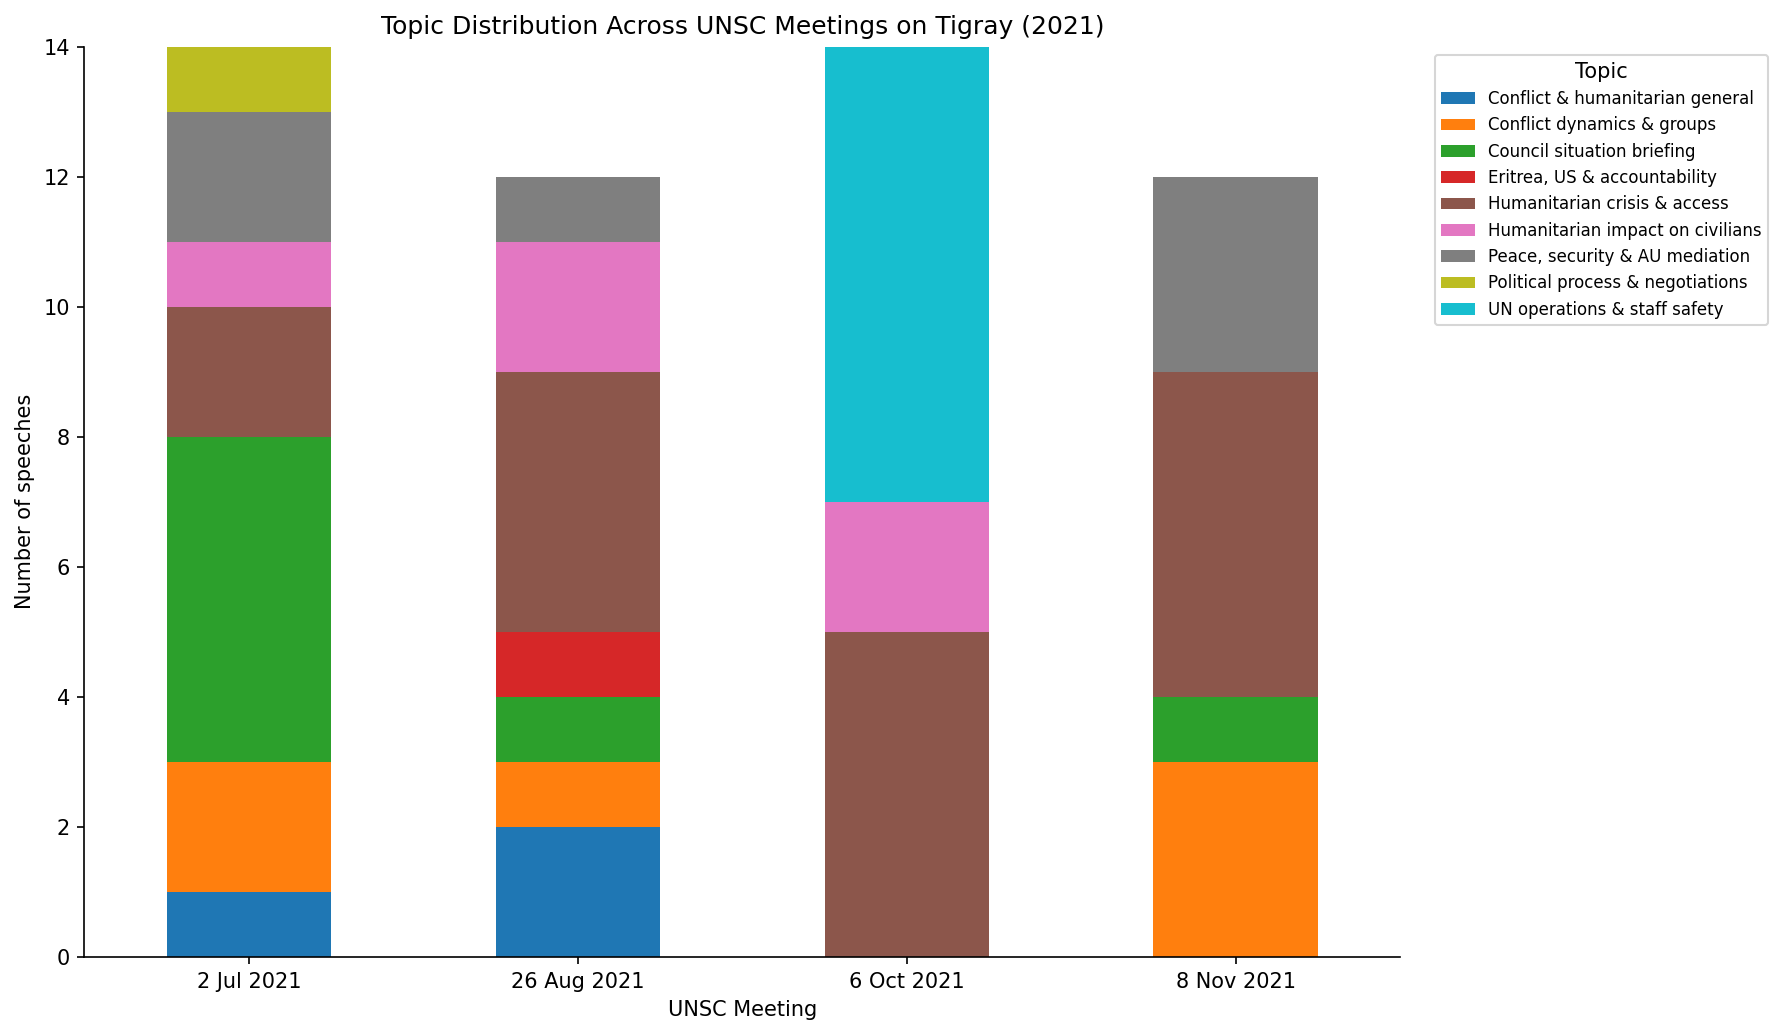

Saved to outputs/figures/topics_over_time.png


In [9]:
# Topics over time (by meeting date, substantive topics only)
meetings = df[
    (df["document_id"].str.startswith("S/PV")) & 
    (~df["topic"].isin([-1, 3, 8]))
]

# Cross-tabulation by meeting date and topic
ct_time = pd.crosstab(
    meetings["document_id"], 
    meetings["topic_label"]
)

# Sort by meeting date
meeting_order = ["S/PV.8812", "S/PV.8843", "S/PV.8875", "S/PV.8899"]
meeting_dates = {
    "S/PV.8812": "2 Jul 2021",
    "S/PV.8843": "26 Aug 2021",
    "S/PV.8875": "6 Oct 2021",
    "S/PV.8899": "8 Nov 2021",
}

ct_time = ct_time.reindex(meeting_order)
ct_time.index = [meeting_dates[m] for m in meeting_order]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
ct_time.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel("UNSC Meeting")
ax.set_ylabel("Number of speeches")
ax.set_title("Topic Distribution Across UNSC Meetings on Tigray (2021)")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/figures/topics_over_time.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/topics_over_time.png")

## Step 6: Robustness Check — Speeches Only

BERTopic may cluster documents by genre (press releases vs. speeches) rather than by theme. To test this, we re-run the model on the 75 UNSC speeches only, excluding press releases, letters, and the Council statement. If the thematic structure holds, our findings are robust.

In [10]:
# Filter to speeches only (from verbatim records)
df_speeches_only = df[df["document_id"].str.startswith("S/PV")].copy()
docs_speeches = df_speeches_only["text"].tolist()

print(f"Speeches-only corpus: {len(docs_speeches)} documents")

# Generate embeddings for speeches only
embeddings_speeches = embedding_model.encode(docs_speeches, show_progress_bar=True)

# Fit a new BERTopic model
umap_speeches = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_speeches = HDBSCAN(
    min_cluster_size=3,
    min_samples=2,
    metric="euclidean",
    prediction_data=True
)

topic_model_speeches = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_speeches,
    hdbscan_model=hdbscan_speeches,
    vectorizer_model=vectorizer_model,
    verbose=True
)

topics_s, probs_s = topic_model_speeches.fit_transform(docs_speeches, embeddings_speeches)

# Results
topic_info_s = topic_model_speeches.get_topic_info()
print(f"\nTopics found: {len(topic_info_s) - 1}")
print(f"Outliers: {sum(t == -1 for t in topics_s)}")
print(f"Assigned: {sum(t != -1 for t in topics_s)}")

print("\n=== TOPIC LABELS (SPEECHES ONLY) ===\n")
print(topic_info_s[["Topic", "Count", "Name"]].to_string())

print("\n=== TOP WORDS PER TOPIC ===\n")
for topic_id in range(len(topic_info_s) - 1):
    words = topic_model_speeches.get_topic(topic_id)
    if words:
        word_list = ", ".join([w[0] for w in words[:8]])
        print(f"Topic {topic_id} (n={topic_info_s[topic_info_s['Topic']==topic_id]['Count'].values[0]}): {word_list}")

Speeches-only corpus: 75 documents


Batches: 100%|██████████| 3/3 [00:00<00:00,  4.10it/s]
2026-03-17 13:08:48,919 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-17 13:08:48,975 - BERTopic - Dimensionality - Completed ✓
2026-03-17 13:08:48,975 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-17 13:08:48,977 - BERTopic - Cluster - Completed ✓
2026-03-17 13:08:48,978 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-17 13:08:49,002 - BERTopic - Representation - Completed ✓



Topics found: 1
Outliers: 0
Assigned: 75

=== TOPIC LABELS (SPEECHES ONLY) ===

   Topic  Count                                   Name
0      0     71  0_humanitarian_ethiopia_tigray_people
1      1      4                1_mr_ms_agenda_speeches

=== TOP WORDS PER TOPIC ===

Topic 0 (n=71): humanitarian, ethiopia, tigray, people, united, conflict, nations, security


In [11]:
# Robustness check with k-means clustering instead of HDBSCAN
from sklearn.cluster import KMeans

# Try with 6 clusters (comparable to the number of substantive topics in full model)
kmeans_model = KMeans(n_clusters=6, random_state=42, n_init=10)

topic_model_speeches_v2 = BERTopic(
    embedding_model=embedding_model,
    umap_model=UMAP(n_neighbors=10, n_components=5, min_dist=0.0, 
                    metric="cosine", random_state=42),
    hdbscan_model=kmeans_model,
    vectorizer_model=vectorizer_model,
    verbose=True
)

topics_s2, probs_s2 = topic_model_speeches_v2.fit_transform(docs_speeches, embeddings_speeches)

# Results
topic_info_s2 = topic_model_speeches_v2.get_topic_info()
print(f"Topics found: {len(topic_info_s2)}")

print("\n=== TOPIC LABELS (SPEECHES ONLY, K-MEANS) ===\n")
print(topic_info_s2[["Topic", "Count", "Name"]].to_string())

print("\n=== TOP WORDS PER TOPIC ===\n")
for topic_id in range(len(topic_info_s2)):
    words = topic_model_speeches_v2.get_topic(topic_id)
    if words:
        word_list = ", ".join([w[0] for w in words[:8]])
        print(f"Topic {topic_id} (n={topic_info_s2[topic_info_s2['Topic']==topic_id]['Count'].values[0]}): {word_list}")

2026-03-17 13:09:36,539 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-17 13:09:36,605 - BERTopic - Dimensionality - Completed ✓
2026-03-17 13:09:36,606 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-17 13:09:36,646 - BERTopic - Cluster - Completed ✓
2026-03-17 13:09:36,647 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-17 13:09:36,675 - BERTopic - Representation - Completed ✓


Topics found: 6

=== TOPIC LABELS (SPEECHES ONLY, K-MEANS) ===

   Topic  Count                                     Name
0      0     21   0_humanitarian_ethiopia_united_nations
1      1     15    1_humanitarian_ethiopia_people_tigray
2      2     14        2_ethiopia_council_peace_security
3      3     14  3_tigray_humanitarian_ethiopia_conflict
4      4      7        4_floor_briefing_thank_statements
5      5      4                  5_mr_ms_agenda_speeches

=== TOP WORDS PER TOPIC ===

Topic 0 (n=21): humanitarian, ethiopia, united, nations, united nations, people, tigray, ethiopian
Topic 1 (n=15): humanitarian, ethiopia, people, tigray, ethiopian, government, international, situation
Topic 2 (n=14): ethiopia, council, peace, security, african, africa, humanitarian, parties
Topic 3 (n=14): tigray, humanitarian, ethiopia, conflict, human, rights, parties, government
Topic 4 (n=7): floor, briefing, thank, statements, make, members, wish, council
Topic 5 (n=4): mr, ms, agenda, speeches,

### Robustness Check Results

With k-means (k=6) on speeches only, four substantive themes emerge:
1. **UN humanitarian operations** (n=21): Focus on UN agencies, aid delivery, and organizational response.
2. **Humanitarian crisis and civilians** (n=15): Focus on civilian suffering, government responsibility, and the situation on the ground.
3. **Peace, security, and AU mediation** (n=14): Focus on ceasefire, African Union efforts, and political dialogue.
4. **Conflict, human rights, and accountability** (n=14): Focus on violations, human rights, and the conduct of parties.

Two procedural clusters (n=11 combined) capture presidential transitions and agenda items.

These themes are consistent with the full corpus model, confirming that the core framing structure is not an artifact of mixing document types. The humanitarian frame dominates in both models, and the peace/mediation vs. accountability distinction persists.

In [12]:
# Save the speeches-only topic assignments
df_speeches_only = df_speeches_only.copy()
df_speeches_only["topic_kmeans"] = topics_s2

speeches_topic_labels = {
    0: "UN humanitarian operations",
    1: "Humanitarian crisis & civilians",
    2: "Peace, security & AU mediation",
    3: "Conflict, human rights & accountability",
    4: "Procedural (floor/briefing)",
    5: "Procedural (agenda/record)",
}
df_speeches_only["topic_kmeans_label"] = df_speeches_only["topic_kmeans"].map(speeches_topic_labels)

# Save updated corpus with both topic assignments
df.to_csv("data/processed/corpus_with_topics.csv", index=False)
df_speeches_only.to_csv("data/processed/speeches_with_topics.csv", index=False)

print("Saved: corpus_with_topics.csv and speeches_with_topics.csv")
print(f"\n=== SPEECHES-ONLY TOPIC DISTRIBUTION BY COUNTRY ===\n")

# Quick cross-tab for council members
members_s = df_speeches_only[
    (df_speeches_only["role"] == "council_member") & 
    (~df_speeches_only["topic_kmeans"].isin([4, 5]))
]
ct_s = pd.crosstab(members_s["country"], members_s["topic_kmeans_label"])
ct_s["total"] = ct_s.sum(axis=1)
ct_s = ct_s.sort_values("total", ascending=False)
print(ct_s.to_string())

Saved: corpus_with_topics.csv and speeches_with_topics.csv

=== SPEECHES-ONLY TOPIC DISTRIBUTION BY COUNTRY ===

topic_kmeans_label        Conflict, human rights & accountability  Humanitarian crisis & civilians  Peace, security & AU mediation  UN humanitarian operations  total
country                                                                                                                                                              
China                                                           0                                3                               1                           0      4
Estonia                                                         3                                0                               0                           1      4
Ireland                                                         0                                1                               0                           3      4
Norway                                                   